In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config
set_config(display="text")

from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 손글씨 데이터 로드

In [ ]:
# RandomForestClassifier 앙상블 기법

mnist = datasets.load_digits()  # Each datapoint is an 8x8 image of a digit.
features, labels = mnist.data, mnist.target


# 교차 검증 
##### 학습 하는 과정에서 현재의 성능이 어느 정도인가를 체크해 가면서 학습의 방향이 정확도가 높은 것인지
###### n등분한 데이터를 학습 데이터, 테스트 데이터로 분리
###### n번 반복 : 학습 데이터가 반드시 한번은 검증 데이터로 사용 할 수 있다
###### 데이터가 적을 수록 정확도는 낮아질 수 밖에 없음 -> 학습 데이터 전체로 사용하되 검증데이터를 로테이션 하면서 사용하는 방법 : 교차 검증

교차 검증을 10번 수행하여, 10번의 교차 검증 평균 정확도를 저장함.

In [13]:
# 교차 검증을 10번 수행하여, 10번의 교차 검증 평균 정확도를 저장함.

def cross_validation(classifier, features, labels): # 모델, 독립변수, 정답 데이터
    cv_scores = []

    for i in range(10):
        scores = cross_val_score(classifier, features, labels, cv = 10, scoring='accuracy') # cv=cross validation, from sklearn.model_selection
        cv_scores.append(scores.mean())

    return cv_scores    
        

In [14]:
# DecisionTreeClassifier
dt_cv_scores = cross_validation(DecisionTreeClassifier(), features, labels)  # DecisionTreeClassifier(의사결정 모델) 교차 검증

In [15]:
# RandomForestClassifier
rf_cv_scores = cross_validation(RandomForestClassifier(), features, labels) # RandomForestClassifier 모델 교차검증

In [16]:
print(dt_cv_scores)
print(rf_cv_scores)

[np.float64(0.8202048417132215), np.float64(0.8246492861576661), np.float64(0.8324829298572315), np.float64(0.8224705152079453), np.float64(0.831927374301676), np.float64(0.8235971446306642), np.float64(0.8280105524518933), np.float64(0.8297020484171321), np.float64(0.824683426443203), np.float64(0.8196865301055245)]
[np.float64(0.9504655493482309), np.float64(0.9448975791433891), np.float64(0.9549224084419615), np.float64(0.9449037864680323), np.float64(0.951024208566108), np.float64(0.948786468032278), np.float64(0.9493513345747981), np.float64(0.9526939788950962), np.float64(0.9465704531346988), np.float64(0.9504655493482309)]


# 랜덤포레스트 vs 의사결정트리 시각화  

라인 차트를 통해 랜덤포레스트가 의사결정트리보다 정확도가 높은 것을 확인

In [17]:
cv_list = [
    ['random_forest', rf_cv_scores],
    ['decision_tree', dt_cv_scores]
]

df = pd.DataFrame.from_dict(dict(cv_list))  # dictionary 자료형으로 변환

<Axes: >

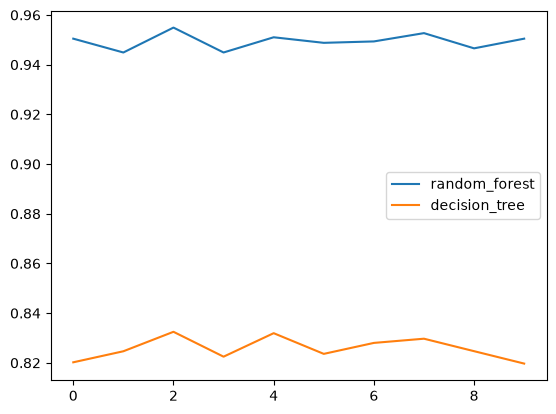

In [18]:
df.plot()

# 의사결정트리 정확도

In [21]:
# DecisionTreeClassifier
np.mean(dt_cv_scores)

np.float64(0.8257414649286157)

# 랜덤포레스트 정확도

In [22]:
# RandomForestClassifier
np.mean(rf_cv_scores)

np.float64(0.9494081315952825)